<a href="https://colab.research.google.com/github/withfablue/ISLP/blob/main/Ch4_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: Logistic Regression, LDA, QDA, KNN

In [1]:
!pip install ISLP
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=657309fd1f969d26d1389513affbbb2eae2c6c3e9bc97280ae3656ced537982c
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


In [2]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression



In [3]:
Smarket = load_data('Smarket')
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


In [4]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [5]:
Smarket.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


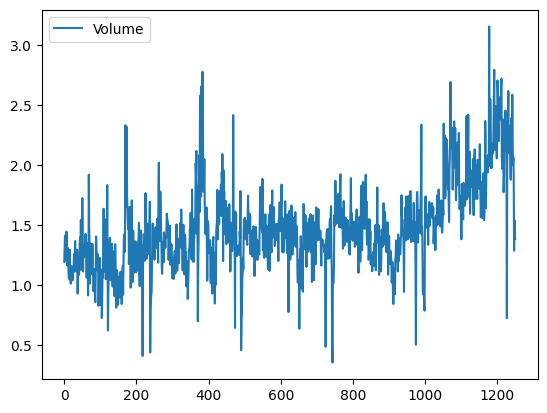

In [6]:
Smarket.plot(y='Volume');

In [7]:
# Logistic Regression
allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Smarket)
y = Smarket.Direction == 'Up'
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
results = glm.fit()
summarize(results)


,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


In [8]:
results.params

,0
intercept,-0.126000
Lag1,-0.073074
Lag2,-0.042301
Lag3,0.011085
Lag4,0.009359
Lag5,0.010313
Volume,0.135441


In [9]:
results.pvalues

,0
intercept,0.600700
Lag1,0.145232
Lag2,0.398352
Lag3,0.824334
Lag4,0.851445
Lag5,0.834998
Volume,0.392404


In [10]:
probs = results.predict()
probs[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

In [11]:
labels = np.array(['Down']*1250)
labels[probs>0.5] = 'Up'

In [12]:
confusion_table(labels, Smarket.Direction)

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


In [13]:
(507+145)/1250, np.mean(labels==Smarket.Direction)

(0.5216, np.float64(0.5216))

In [14]:
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]
Smarket_test.shape


(252, 9)

In [15]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [16]:
D = Smarket.Direction
L_train, L_test = D.loc[train], D.loc[~train]


In [17]:
labels = np.array(['Down']*252)
labels[probs>0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


In [18]:
np.mean(labels==L_test), np.mean(labels!=L_test)

(np.float64(0.4801587301587302), np.float64(0.5198412698412699))

In [19]:
model = MS(['Lag1', 'Lag2']).fit(Smarket)
X = model.transform(Smarket)
X_train, X_test = X.loc[train], X.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)
labels = np.array(["Down"]*252)
labels[probs>0.5] = "Up"
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [20]:
(35+106)/252, 106/(106+76)

(0.5595238095238095, 0.5824175824175825)

In [21]:
newdata = pd.DataFrame({'Lag1': [1.2, 1.5],
                        'Lag2': [1.1, -0.8]});
newX = model.transform(newdata)
results.predict(exog=newX)

,0
0,0.479146
1,0.496094


In [22]:
# LDA
lda = LDA(store_covariance=True)

In [23]:
X_train

,intercept,Lag1,Lag2
0,1.0,0.381,-0.192
1,1.0,0.959,0.381
2,1.0,1.032,0.959
3,1.0,-0.623,1.032
4,1.0,0.614,-0.623
...,...,...,...
993,1.0,0.046,0.342
994,1.0,-0.431,0.046
995,1.0,0.715,-0.431
996,1.0,-0.007,0.715


In [24]:
X_train, X_test= [M.drop(columns=['intercept']) for M in [X_train, X_test]]
lda.fit(X_train, L_train)

LinearDiscriminantAnalysis(store_covariance=True)

In [25]:
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [26]:
lda.priors_

array([0.49198397, 0.50801603])

In [27]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [28]:
lda.scalings_

array([[-0.64201904],
       [-0.51352928]])

In [29]:
lda_pred = lda.predict(X_test)

In [30]:
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [31]:
lda_prob = lda.predict_proba(X_test)
np.all(
    np.where(lda_prob[:,1] >= 0.5, 'Up', 'Down') == lda_pred
)

np.True_

In [32]:
np.all(
    [lda.classes_[i] for i in np.argmax(lda_prob, 1)] == lda_pred
)

np.True_

In [33]:
np.sum(lda_prob[:,0]>0.9)

np.int64(0)

In [34]:
# QDA
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

QuadraticDiscriminantAnalysis(store_covariance=True)

In [35]:
qda.means_, qda.priors_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([0.49198397, 0.50801603]))

In [36]:
qda.covariance_[0]

array([[ 1.50662277, -0.03924806],
       [-0.03924806,  1.53559498]])

In [37]:
qda.covariance_

[array([[ 1.50662277, -0.03924806],
        [-0.03924806,  1.53559498]]),
 array([[ 1.51700576, -0.02787349],
        [-0.02787349,  1.49026815]])]

In [38]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,30,20
Up,81,121


In [39]:
np.mean(qda_pred == L_test)

np.float64(0.5992063492063492)

In [40]:
# Naive Bayes
NB = GaussianNB()
NB.fit(X_train, L_train)

GaussianNB()

In [41]:
NB.classes_

array(['Down', 'Up'], dtype='<U4')

In [42]:
NB.class_prior_

array([0.49198397, 0.50801603])

In [43]:
NB.theta_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [44]:
NB.var_

array([[1.50355429, 1.53246749],
       [1.51401364, 1.48732877]])

In [45]:
NB?

In [46]:
X_train[L_train=='Down'].mean()

,0
Lag1,0.042790
Lag2,0.033894


In [47]:
X_train[L_train=='Down'].var(ddof=0)

,0
Lag1,1.503554
Lag2,1.532467


In [48]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels, L_test)

Truth,Down,Up
Predicted,,
Down,29,20
Up,82,121


In [49]:
NB.predict_proba(X_test)[:5]

array([[0.4873288 , 0.5126712 ],
       [0.47623584, 0.52376416],
       [0.46529531, 0.53470469],
       [0.47484469, 0.52515531],
       [0.49020587, 0.50979413]])

In [50]:
# KNN
knn1 = KNeighborsClassifier(n_neighbors=1)
X_train, X_test = [np.asarray(X) for X in [X_train, X_test]]
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

Truth,Down,Up
Predicted,,
Down,43,58
Up,68,83


In [51]:
(83+43)/252, np.mean(knn1_pred==L_test)

(0.5, np.float64(0.5))

In [52]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3_pred = knn3.fit(X_train, L_train).predict(X_test)
confusion_table(knn3_pred, L_test)
np.mean(knn3_pred==L_test)

np.float64(0.5317460317460317)

In [53]:
Caravan = load_data('Caravan')
Purchase = Caravan.Purchase
Purchase.value_counts()

,count
Purchase,
No,5474
Yes,348


In [54]:
348/5822

0.05977327378907592

In [55]:
feature_df = Caravan.drop(columns=['Purchase'])

In [56]:
scaler = StandardScaler(with_mean=True,
                        with_std=True,
                        copy=True)

In [57]:
scaler.fit(feature_df)
X_std = scaler.transform(feature_df)

In [58]:
feature_std = pd.DataFrame(X_std, columns=feature_df.columns);
feature_std.std()

,0
MOSTYPE,1.000086
MAANTHUI,1.000086
MGEMOMV,1.000086
MGEMLEEF,1.000086
MOSHOOFD,1.000086
...,...
AZEILPL,1.000086
APLEZIER,1.000086
AFIETS,1.000086
AINBOED,1.000086


In [59]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(np.asarray(feature_std),
                            Purchase,
                            test_size=1000,
                            random_state=0)

In [60]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1_pred = knn1.fit(X_train, y_train).predict(X_test)
np.mean(knn1_pred != y_test), np.mean(y_test != "No")

(np.float64(0.111), np.float64(0.067))

In [61]:
confusion_table(knn1_pred, y_test )

Truth,No,Yes
Predicted,,
No,880,58
Yes,53,9


In [62]:
9/(53+9)

0.14516129032258066

In [63]:
for K in range(1,6):
  knn = KNeighborsClassifier(n_neighbors=K)
  knn_pred = knn.fit(X_train, y_train).predict(X_test)
  C = confusion_table(knn_pred, y_test)
  templ = ('K={0:d} # predicted to rent: {1:>2},' +
           ' # who did rent {2:d}, accuracy {3:.1%}')
  pred = C.loc['Yes'].sum()
  did_rent = C.loc['Yes', 'Yes']
  print(templ.format(
      K,
      pred,
      did_rent,
      did_rent/pred
  ))

K=1 # predicted to rent: 62, # who did rent 9, accuracy 14.5%
K=2 # predicted to rent:  6, # who did rent 1, accuracy 16.7%
K=3 # predicted to rent: 20, # who did rent 3, accuracy 15.0%
K=4 # predicted to rent:  4, # who did rent 0, accuracy 0.0%
K=5 # predicted to rent:  7, # who did rent 1, accuracy 14.3%


In [64]:
logit = LogisticRegression(C=1e10, solver='liblinear')
logit.fit(X_train, y_train)
logit_pred = logit.predict_proba(X_test)
logit_labels = np.where(logit_pred[:, 1]>.5, 'Yes', 'No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,931,67
Yes,2,0


In [65]:
logit_labels = np.where(logit_pred[:, 1]>.25, 'Yes', 'No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,913,58
Yes,20,9


In [66]:
9/(20+9)

0.3103448275862069

In [67]:
# Linear regression & Poisson regression
Bike = load_data('Bikeshare')

In [68]:
Bike.shape, Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

In [69]:
# Linear regression
X = MS(['mnth',
         'hr',
         'workingday',
         'temp',
         'weathersit']).fit_transform(Bike)

y = Bike['bikers']
M_lm = sm.OLS(y, X).fit()
summarize(M_lm)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


In [70]:
hr_encode = contrast('hr', 'sum')
mnth_encode = contrast('mnth', 'sum')

In [71]:
X2 = MS([mnth_encode,
         hr_encode,
         'workingday',
         'temp',
         'weathersit']).fit_transform(Bike)
M2_lm = sm.OLS(y, X2).fit()
S2 = summarize(M2_lm)
S2

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


In [72]:
np.sum((M_lm.fittedvalues - M2_lm.fittedvalues)**2)

np.float64(1.5365599959873106e-20)

In [73]:
np.allclose(M_lm.fittedvalues, M2_lm.fittedvalues)

# 변수 코딩 방식에 관계없이 모형의 예측은 동일하다

True

In [74]:
coef_month = S2[S2.index.str.contains('mnth')]['coef']
coef_month

,coef
mnth[Jan],-46.0871
mnth[Feb],-39.2419
mnth[March],-29.5357
mnth[April],-4.6622
mnth[May],26.4700
mnth[June],21.7317
mnth[July],-0.7626
mnth[Aug],7.1560
mnth[Sept],20.5912
mnth[Oct],29.7472


In [75]:
months = Bike['mnth'].dtype.categories
months

Index(['Jan', 'Feb', 'March', 'April', 'May', 'June', 'July', 'Aug', 'Sept',
       'Oct', 'Nov', 'Dec'],
      dtype='object')

In [76]:
coef_month = pd.concat([coef_month, pd.Series([-coef_month.sum()],
                                               index=['mnth[Dec]'])])
coef_month


,0
mnth[Jan],-46.0871
mnth[Feb],-39.2419
mnth[March],-29.5357
mnth[April],-4.6622
mnth[May],26.4700
mnth[June],21.7317
mnth[July],-0.7626
mnth[Aug],7.1560
mnth[Sept],20.5912
mnth[Oct],29.7472


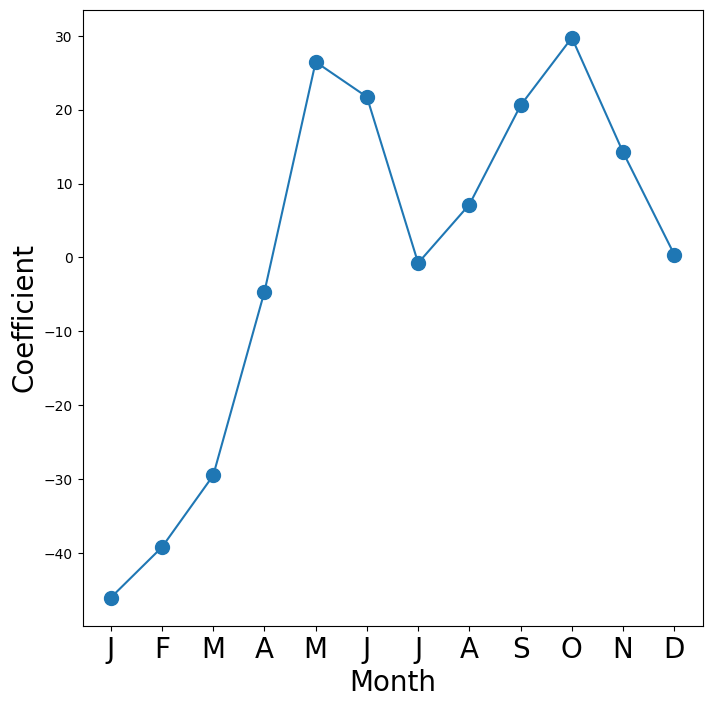

In [77]:
fig_month, ax_month = subplots(figsize=(8,8))
x_month = np.arange(coef_month.shape[0])
ax_month.plot(x_month, coef_month, marker='o', ms=10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index], fontsize=20)
ax_month.set_xlabel('Month', fontsize=20)
ax_month.set_ylabel('Coefficient', fontsize=20);

In [78]:
coef_hr = S2[S2.index.str.contains('hr')]['coef']
coef_hr

,coef
hr[0],-96.1420
hr[1],-110.7213
hr[2],-117.7212
hr[3],-127.2828
hr[4],-133.0495
hr[5],-120.2775
hr[6],-75.5424
hr[7],23.9511
hr[8],127.5199
hr[9],24.4399


In [79]:
coef_hr = S2[S2.index.str.contains('hr')]['coef']
coef_hr = coef_hr.reindex(['hr[{0}]'.format(h) for h in range(23)])
coef_hr = pd.concat([coef_hr,
                     pd.Series([-coef_hr.sum()], index=['hr[23]'])])


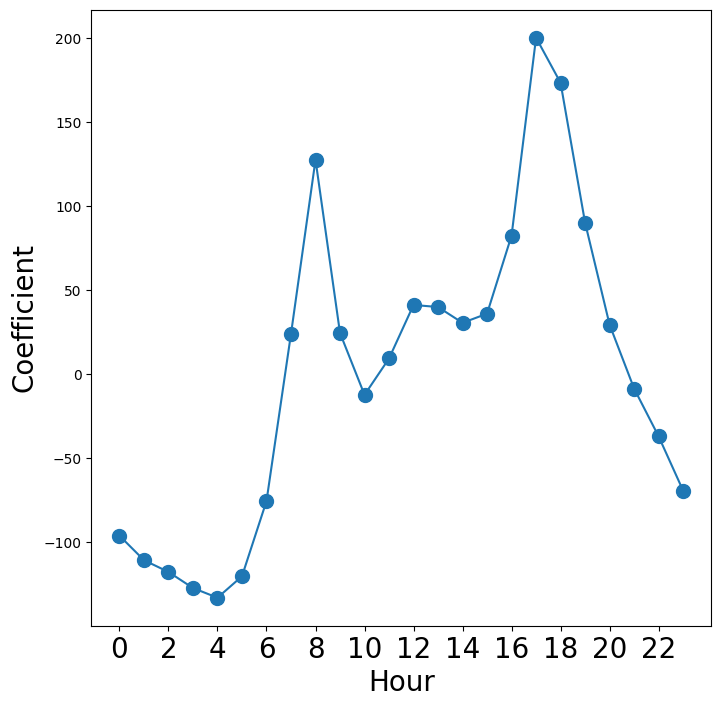

In [80]:
fig_hr, ax_hr = subplots(figsize=(8,8))
x_hr = np.arange(coef_hr.shape[0])
ax_hr.plot(x_hr, coef_hr, marker='o', ms=10)
ax_hr.set_xticks(x_hr[::2])
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)
ax_hr.set_xlabel('Hour', fontsize=20)
ax_hr.set_ylabel('Coefficient', fontsize=20);

In [81]:
# Poisson regression
M_pois = sm.GLM(y, X2, family=sm.families.Poisson()).fit()

In [82]:
S_pois = summarize(M_pois)
coef_month = S_pois[S_pois.index.str.contains('mnth')]['coef']
coef_month = pd.concat([coef_month,
                        pd.Series([-coef_month.sum()], index=['mnth[Dec]'])])
coef_hr = S_pois[S_pois.index.str.contains('hr')]['coef']
coef_hr = pd.concat([coef_hr,
                     pd.Series([-coef_hr.sum()], index=['hr[23]'])])

/tmp/ipykernel_3625/251818762.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_hr.set_xticklabels(range(24)[::2], fontsize=20)


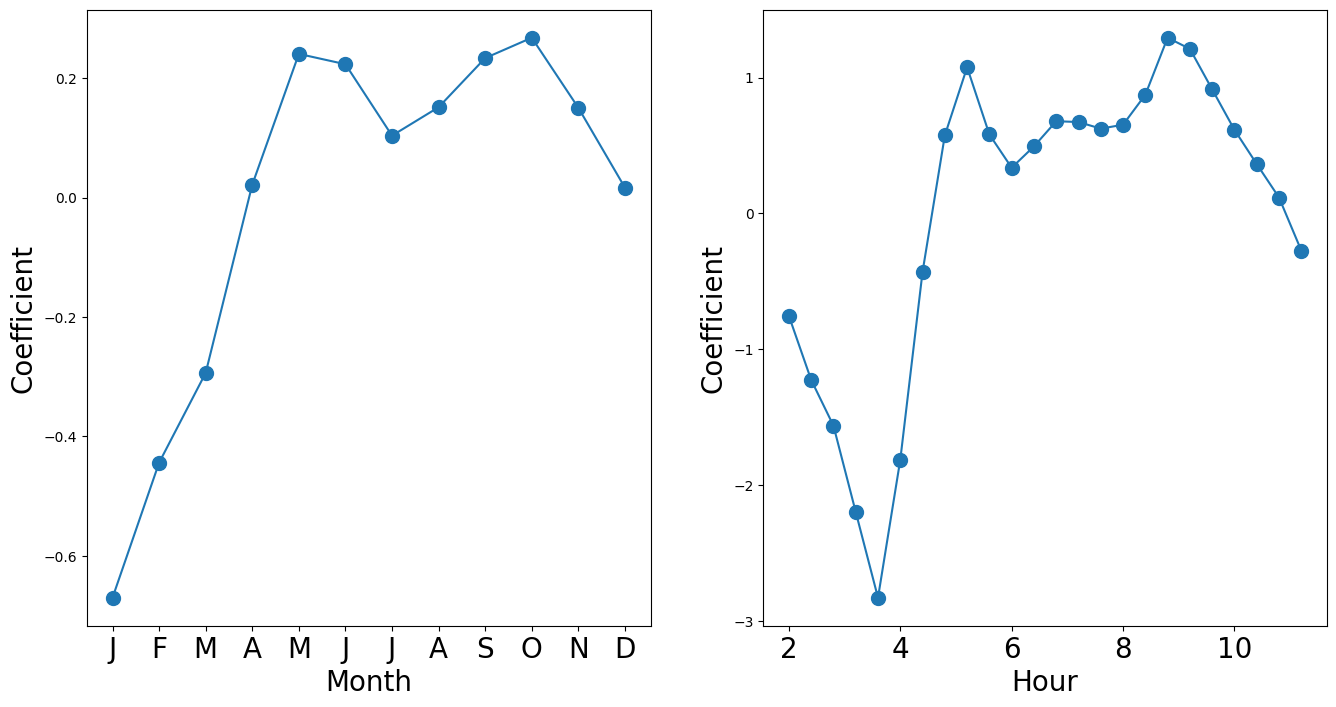

In [83]:
fig_pois, (ax_month, ax_hr) = subplots(1, 2, figsize=(16,8))
ax_month.plot(x_month, coef_month, marker='o', ms=10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index], fontsize=20)
ax_month.set_xlabel('Month', fontsize=20)
ax_month.set_ylabel('Coefficient', fontsize=20);
ax_hr.plot(x_hr, coef_hr, marker='o', ms=10)
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)
ax_hr.set_xlabel('Hour', fontsize=20)
ax_hr.set_ylabel('Coefficient', fontsize=20);

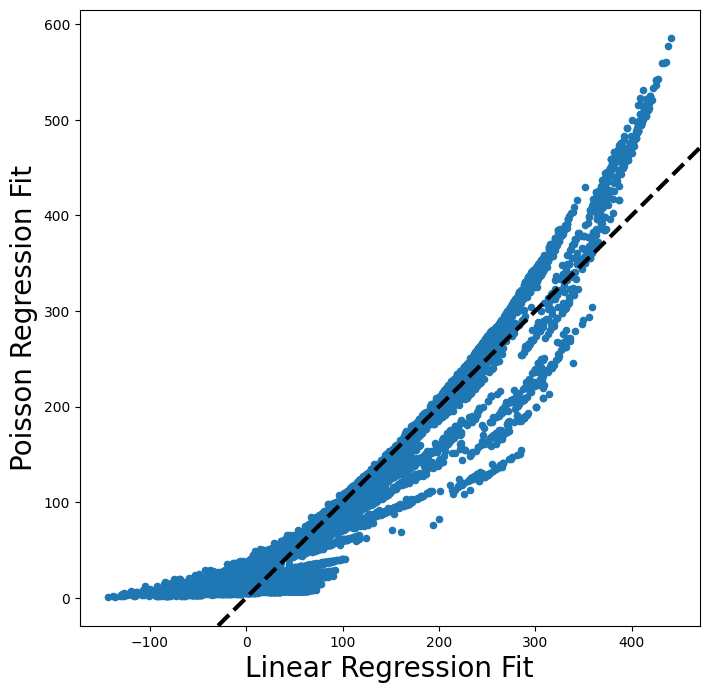

In [84]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(M2_lm.fittedvalues,
           M_pois.fittedvalues,
           s=20)
ax.set_xlabel('Linear Regression Fit', fontsize=20)
ax.set_ylabel('Poisson Regression Fit', fontsize=20)
ax.axline([0,0], c='black', linewidth=3, linestyle='--', slope=1)

In [87]:
Weekly = load_data('Weekly')
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


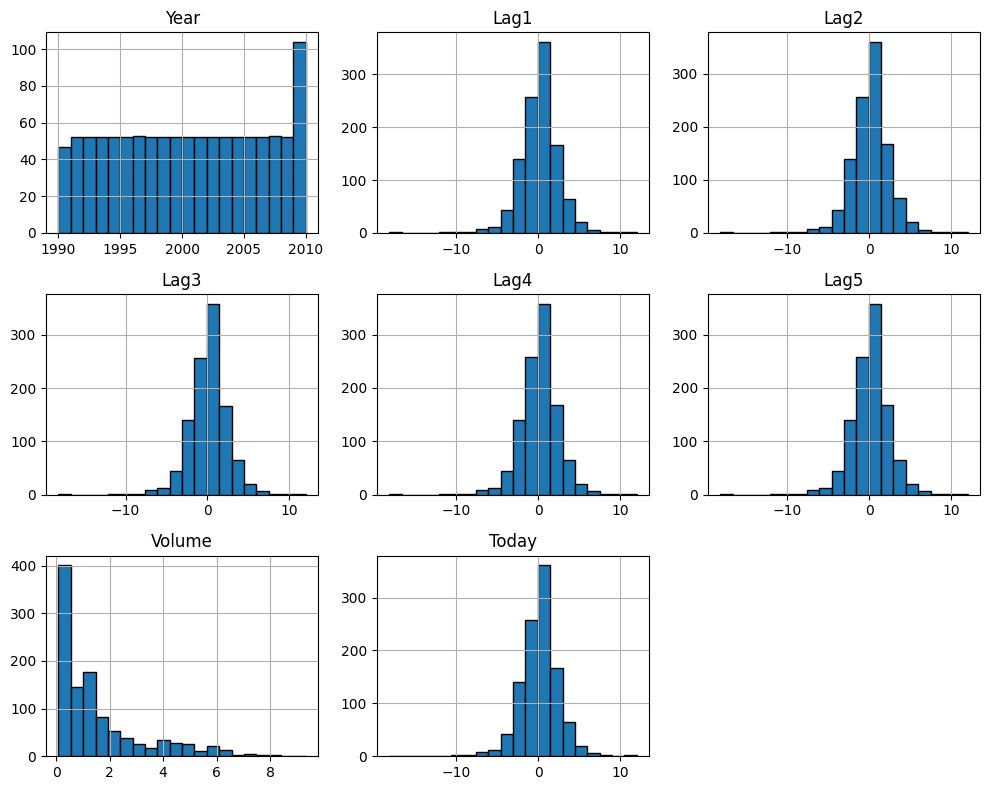

In [88]:
import matplotlib.pyplot as plt
Weekly.hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

In [96]:
Weekly.columns
print(Weekly.dtypes)

Year            int64
Lag1          float64
Lag2          float64
Lag3          float64
Lag4          float64
Lag5          float64
Volume        float64
Today         float64
Direction    category
dtype: object


In [97]:
allvars = Weekly.columns.drop(['Year', 'Today', 'Direction'])
X = MS(allvars).fit_transform(Weekly)
y = Weekly.Direction == 'Up'
Logreg = sm.GLM(y, X, family=sm.families.Binomial()).fit()
Logreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Wed, 23 Sep 2026   Deviance:                       1486.4
Time:                        03:03:05   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.030       0.006       0.111
Lag3          -0.0161      0.027     -0.602      0.547      -0.068       0.036
Lag4          -0.0278      0.026     -1.050      0.294      -0.080       0.024
Lag5          -0.0145      0.026     -0.549      0.583      -0.066       0.037
Volume        -0.0227      0.037     -0.616      0.538      -0.095       0.050
==============================================================================
"""

In [98]:
probs = Logreg.predict()
labels = np.array(['Down']*1089)
labels[probs>0.5] = 'Up'
confusion_table(labels, Weekly.Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [99]:
total_acc = (54+557)/1089
total_acc

0.5610651974288338

In [100]:
Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [104]:
test.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2009.500000,0.397635,0.371365,0.377548,0.369250,0.319058,5.066105,0.333298
std,0.502421,3.068538,3.074725,3.075192,3.073895,3.073650,1.147652,3.003296
min,2009.000000,-7.035000,-7.035000,-7.035000,-7.035000,-7.035000,2.390427,-7.035000
25%,2009.000000,-1.060750,-1.214250,-1.214250,-1.214250,-1.323250,4.234228,-1.060750
50%,2009.500000,0.522000,0.461500,0.522000,0.461500,0.437000,4.850717,0.461500
75%,2010.000000,2.239250,2.239250,2.239250,2.239250,2.204250,5.793837,2.204250
max,2010.000000,10.707000,10.707000,10.707000,10.707000,10.707000,7.963276,10.707000


In [103]:
train = Weekly.loc[Weekly['Year']<2009]
test = Weekly.loc[Weekly['Year'] >= 2009]
design = MS(['Lag2']).fit(train)
X_train = design.transform(train)
y_train = train.Direction == "Up"

X_test = design.transform(test)
y_test = test.Direction == 'Up'

glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm.fit()

test_prob = results.predict(X_test)
test_labels = np.array(['Down']*test_prob.shape[0])
test_labels[test_prob>0.5] = 'Up'
confusion_table(test_labels, test.Direction)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [105]:
acc = 65/104
acc

0.625

In [107]:
lda = LDA(store_covariance=True)
X_train, X_test = [M.drop(columns='intercept') for M in [X_train, X_test]]
L_train, L_test = [M.Direction for M in [train, test]]
lda.fit(X_train, L_train)
lda_pred = lda.predict(X_test)
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [108]:
qda = QDA(store_covariance=True)

qda.fit(X_train, L_train)
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [109]:
knn = KNeighborsClassifier(n_neighbors=1)
X_train, X_test = [np.asarray(X) for X in [X_train, X_test]]
knn.fit(X_train, L_train)
knn_pred = knn.predict(X_test)
confusion_table(knn_pred, L_test)

Truth,Down,Up
Predicted,,
Down,22,32
Up,21,29


In [111]:
NB = GaussianNB()
NB.fit(X_train, L_train)
NB_pred = NB.predict(X_test)
confusion_table(NB_pred, L_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [112]:
knn = KNeighborsClassifier(n_neighbors=3)
X_train, X_test = [np.asarray(X) for X in [X_train, X_test]]
knn.fit(X_train, L_train)
knn_pred = knn.predict(X_test)
confusion_table(knn_pred, L_test)

Truth,Down,Up
Predicted,,
Down,16,19
Up,27,42


In [123]:
# Auto
Auto = load_data('Auto')
med = Auto.mpg.median()
mpg01 = pd.Series(Auto['mpg']>med).astype(int)
Auto['mpg01'] = mpg01
Auto.mpg01

,mpg01
name,
chevrolet chevelle malibu,0
buick skylark 320,0
plymouth satellite,0
amc rebel sst,0
ford torino,0
...,...
ford mustang gl,1
vw pickup,1
dodge rampage,1


In [136]:
Auto.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,int64
weight,int64
acceleration,float64
year,int64
origin,int64
mpg01,int64


<Axes: >

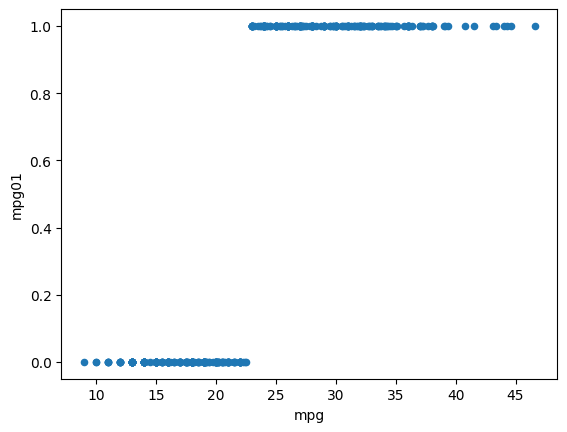

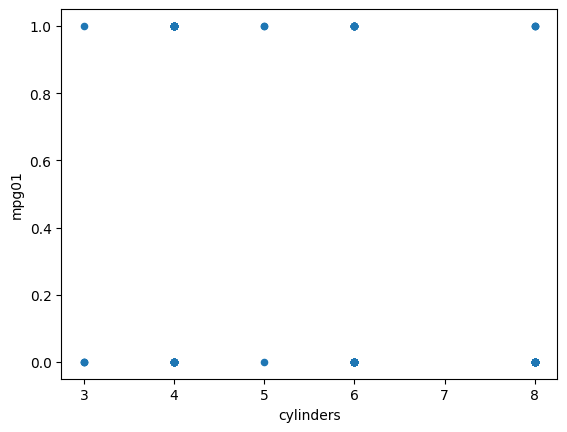

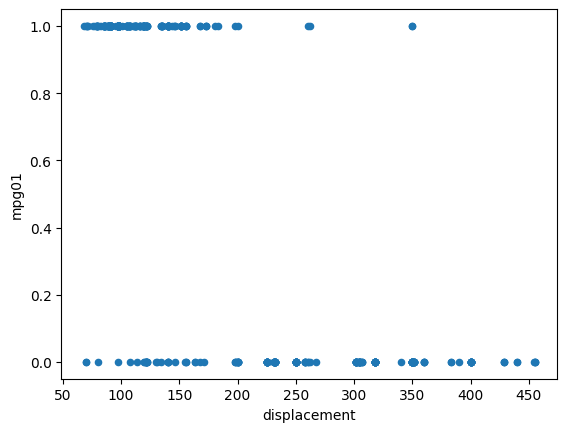

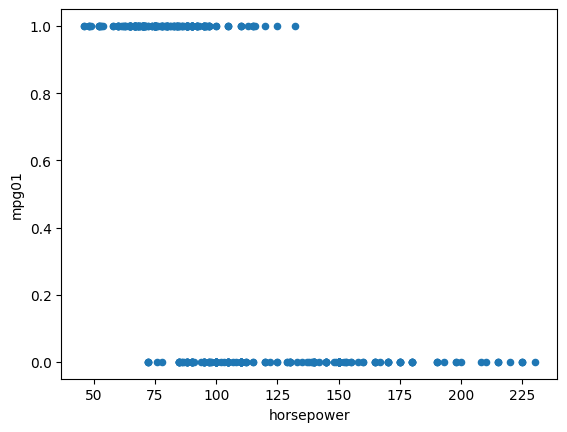

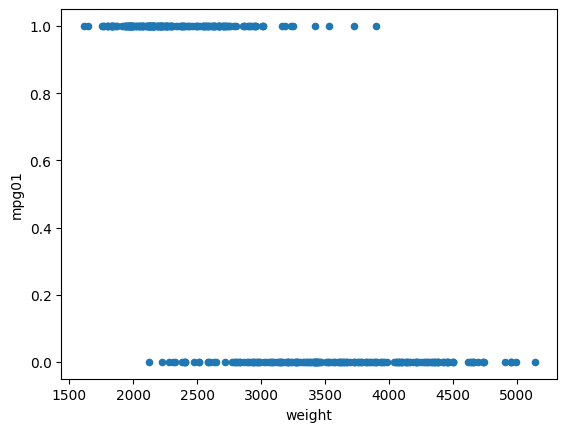

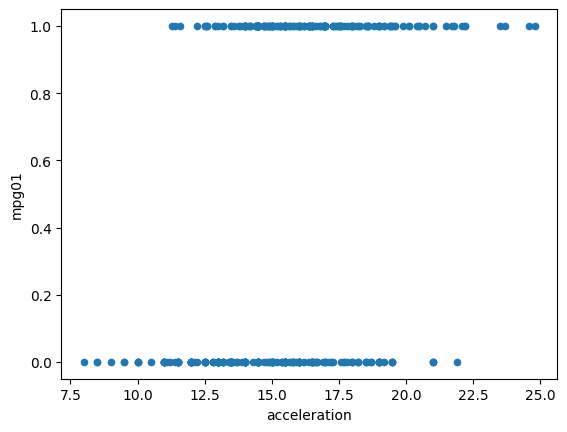

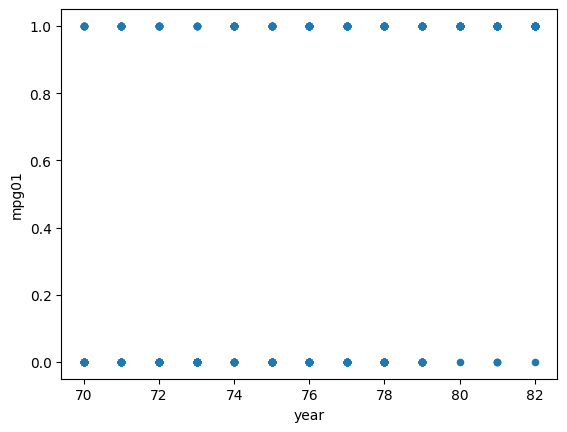

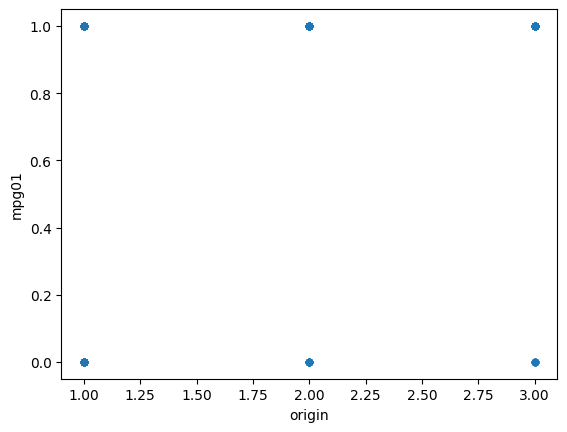

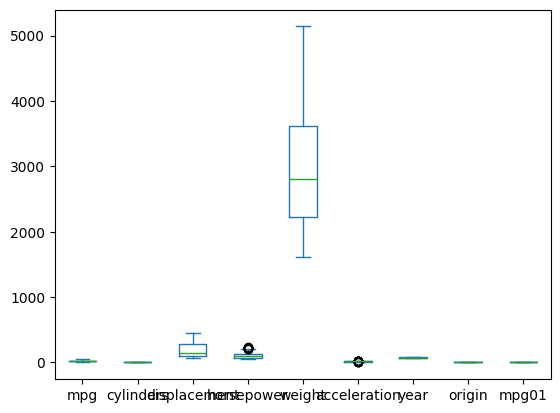

In [138]:
for column in Auto.columns:
  if column != 'mpg01':
    Auto.plot.scatter(column, 'mpg01')


Auto.plot.box()



In [142]:
vars = ['horsepower', 'weight', 'acceleration']
(X_train, X_test, y_train, y_test) = train_test_split(np.asarray(Auto[vars]), Auto.mpg01, test_size=50, random_state=0)

In [146]:

lda.fit(X_train, y_train)
lda_pred = lda.predict(X_test)
confusion_table(lda_pred, y_test)

Truth,0,1
Predicted,,
0,20,1
1,8,21


In [144]:
lda_acc = 41/50

In [150]:
qda.fit(X_train, y_train)
qda_pred = qda.predict(X_test)
qda_acc = np.mean(qda_pred == y_test)
qda_acc


np.float64(0.84)

In [167]:
df_train, df_test = [pd.DataFrame(X, columns=vars) for X in [X_train, X_test]]
y_train, y_test = [np.asarray(y) for y in [y_train, y_test]]

design = MS(vars).fit(df_train)
X = design.transform(df_train)
Xt = design.transform(df_test)

model = sm.GLM(y_train, X, family=sm.families.Binomial())
results = model.fit()
prob = results.predict(Xt)
labels = np.array([0]*prob.shape[0])
labels[prob>0.5] = 1
lr_acc = np.mean(labels==y_test)
lr_acc

np.float64(0.86)

In [171]:
NB = GaussianNB()
NB.fit(X_train, y_train)
NB_pred = NB.predict(X_test)
nb_acc = np.mean(NB_pred == y_test)
nb_acc

np.float64(0.84)

In [172]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
knn1_pred = knn1.predict(X_test)
knn1_acc = np.mean(knn1_pred == y_test)
knn1_acc

np.float64(0.8)

In [173]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
knn3_pred = knn3.predict(X_test)
knn3_acc = np.mean(knn3_pred == y_test)
knn3_acc

np.float64(0.86)

In [175]:
knn10 = KNeighborsClassifier(n_neighbors=10)
knn10.fit(X_train, y_train)
knn10_pred = knn10.predict(X_test)
knn10_acc = np.mean(knn10_pred == y_test)
knn10_acc

np.float64(0.88)

In [176]:
lda_acc, qda_acc, lr_acc, nb_acc, knn1_acc, knn3_acc, knn10_acc

(0.82,
 np.float64(0.84),
 np.float64(0.86),
 np.float64(0.84),
 np.float64(0.8),
 np.float64(0.86),
 np.float64(0.88))

In [177]:
def Power():
  print(2**3)

Power()

8


In [179]:
def Power2(x, a):
  print(x**a)

Power2(3, 8)

6561


In [180]:
Power2(10, 3), Power2(8, 17), Power2(131, 3)

1000
2251799813685248
2248091


(None, None, None)

In [181]:
def Power3(x, a):
  result = x**a
  return result

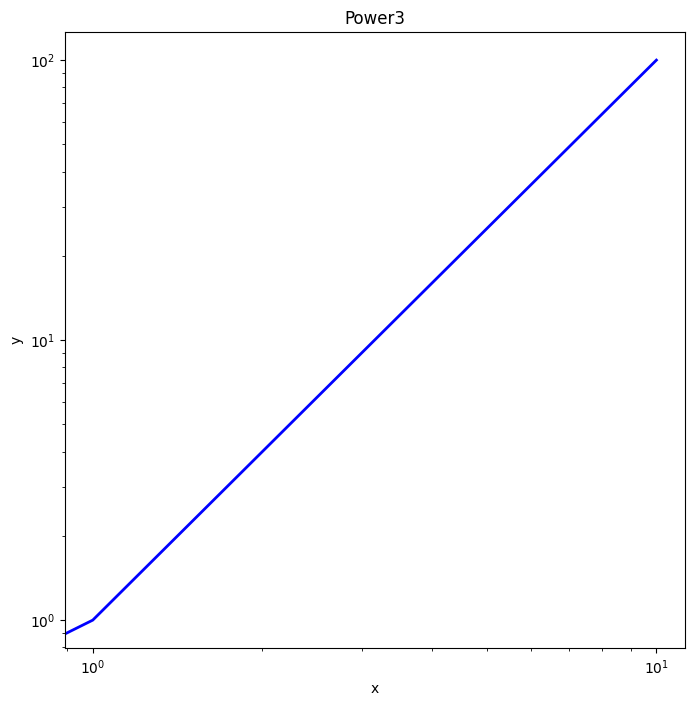

In [187]:
x = np.arange(0, 11, 1)
y = Power3(x, 2)

fig, ax = subplots(figsize=(8,8))
ax.set_yscale('log')
ax.set_xscale('log')
ax.plot(x, y, c='b', lw=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Power3')




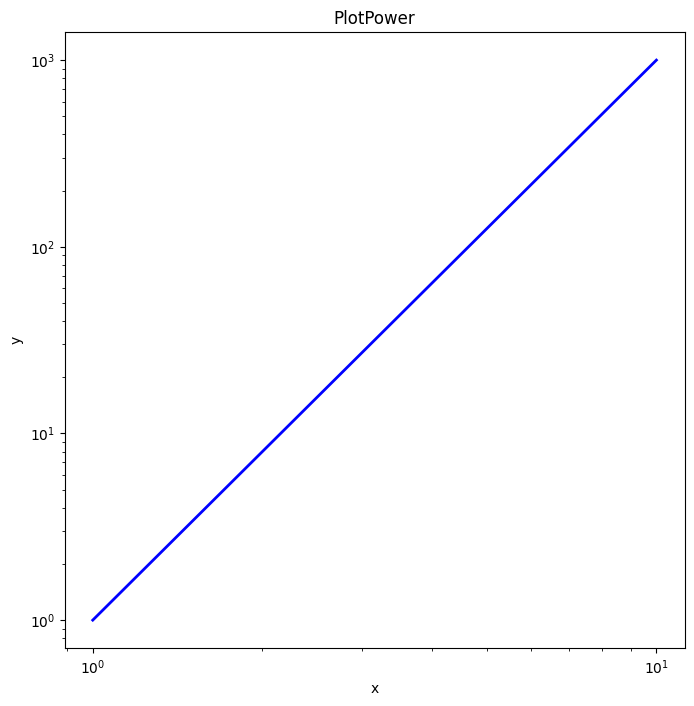

In [189]:
def PlotPower(x, a):
  y = Power3(x, a)

  fig, ax = subplots(figsize=(8,8))
  ax.set_yscale('log')
  ax.set_xscale('log')
  ax.plot(x, y, c='b', lw=2)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_title('PlotPower')

PlotPower(np.arange(1,11), 3)